In [17]:
import numpy as np
import pandas as pd
df=pd.read_csv("Wine dataset.csv")
df.head()

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proli

In [3]:
df['class'].value_counts()

class
2    71
1    59
3    48
Name: count, dtype: int64

In [4]:
X=df.drop('class',axis=1)
Y=df['class']

In [5]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
Y=le.fit_transform(Y)
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2], dtype=int64)

In [6]:
Y=pd.DataFrame(Y)
Y.value_counts()

0
1    71
0    59
2    48
Name: count, dtype: int64

In [7]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
X_scaled=ss.fit_transform(X)
X_scaled=pd.DataFrame(X_scaled)
X_scaled.columns=list(X)
X_scaled.head()

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X_scaled,Y, test_size=0.2, random_state=42)

In [11]:
# Create Model
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(13, input_dim=x_train.shape[1])) # Input Layer
model.add(Dense(12, activation='relu'))# Hidden Layer
model.add(Dense(3, activation='softmax'))# Output Layer for 3 classes

C:\Users\Alokp\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# model compile
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [13]:
#fit model
history=model.fit(x_train, y_train, validation_split=0.2, epochs=50, batch_size=10,verbose=1)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.4602 - loss: 1.2496 - val_accuracy: 0.5172 - val_loss: 1.0999
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5133 - loss: 1.0756 - val_accuracy: 0.5517 - val_loss: 0.9801
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6106 - loss: 0.9408 - val_accuracy: 0.5517 - val_loss: 0.8820
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6726 - loss: 0.8337 - val_accuracy: 0.6552 - val_loss: 0.7920
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7080 - loss: 0.7450 - val_accuracy: 0.6897 - val_loss: 0.7111
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7522 - loss: 0.6670 - val_accuracy: 0.6897 - val_loss: 0.6368
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7965 - loss: 0.5956 - val_accuracy: 0.7931 - val_loss: 0.5701
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8319 - loss: 0.5331 - val_accuracy: 0.7931 - v

In [ ]:
#model evaluation

In [14]:
y_pred = model.predict(x_test)
y_pred

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


array([[9.9937743e-01, 3.9583360e-04, 2.2666760e-04],
       [9.9885142e-01, 6.7673542e-04, 4.7188450e-04],
       [3.1825628e-03, 6.5905722e-03, 9.9022686e-01],
       [9.9628437e-01, 2.8681238e-03, 8.4757438e-04],
       [1.7205434e-03, 9.9758637e-01, 6.9305865e-04],
       [9.9824417e-01, 5.4731820e-04, 1.2085662e-03],
       [3.4306042e-05, 9.9993181e-01, 3.3830365e-05],
       [1.9328451e-03, 1.6485415e-03, 9.9641860e-01],
       [5.1986841e-03, 9.9440706e-01, 3.9428435e-04],
       [3.6070079e-03, 7.7126264e-03, 9.8868036e-01],
       [9.8768193e-01, 9.6758222e-03, 2.6422325e-03],
       [4.3797580e-04, 9.3714613e-04, 9.9862492e-01],
       [9.6257234e-01, 2.8532643e-02, 8.8950442e-03],
       [5.6480747e-03, 9.5505345e-01, 3.9298482e-02],
       [9.9954778e-01, 2.6071689e-04, 1.9144308e-04],
       [7.2331633e-04, 9.9875402e-01, 5.2264234e-04],
       [2.8672193e-05, 9.9993372e-01, 3.7662550e-05],
       [7.1728580e-05, 9.9987650e-01, 5.1784671e-05],
       [9.9965060e-01, 2.145

In [15]:
y_pred.shape

(36, 3)

In [18]:
y_pred_class = np.argmax(y_pred,axis=1)
y_pred_class

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0], dtype=int64)

In [20]:
# print evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix
print("Confusion matrix", confusion_matrix(y_test, y_pred_class))

Confusion matrix [[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]


In [21]:
print("Accuracy",accuracy_score(y_test, y_pred_class))

Accuracy 1.0


In [22]:
# Step 7: Plot Training and Validation Accuracies

# Extract accuracy history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)

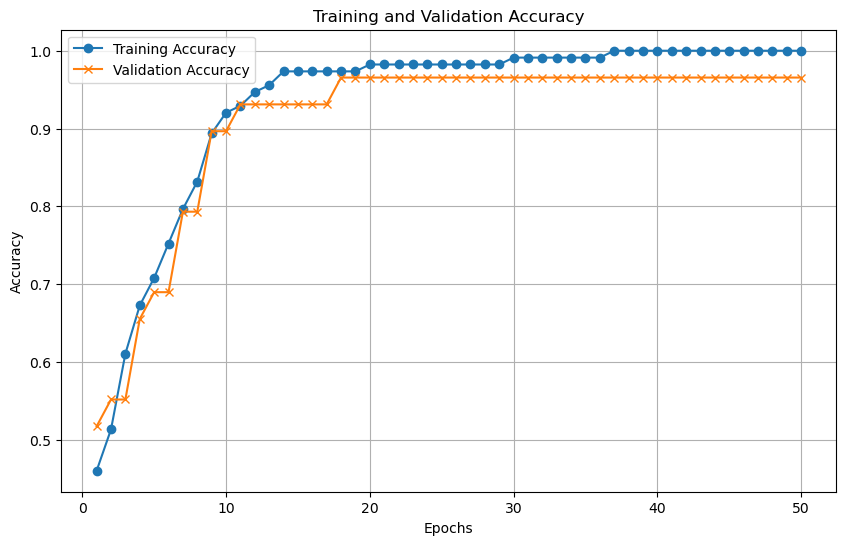

In [23]:
# Plotting the accuracies
# Import necessary libraries for plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker='x')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)
plt.show()